<a href="https://colab.research.google.com/github/uditnarayanpandey/Machine_Learning_Practice/blob/Master/Deep%20Learning/src/MNIST_FASHION_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Multiclass Clasification Using **ANN**

---
This is just a sample code to learn the implementation of **Deep Learning Algorithms** using **Pytorch**

### 1. **Importing Necessary Libraries**

---
Importing all the necessary libraries that would be required to manipulation of the dataset along with visualizing the graphs

In [ ]:
# Import numpy
import numpy as np

# Importing torch libraries
import torch
from torch import nn
from torch.utils.data import Dataset
from torchvision import datasets
from torch.utils.data import SubsetRandomSampler
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import ToTensor, Normalize, Compose
import matplotlib.pyplot as plt

In [ ]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(device)

cuda


### 2. **Loading The Dataset**

---
Load the dataset from torch Datasets

In [ ]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26421880/26421880 [00:06<00:00, 4227809.16it/s]


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 301147.67it/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:02<00:00, 2201776.28it/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 4953493.23it/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [ ]:
# Determine the size of the training and validation sets
# train_size = int(0.8 * len(training_data))  # 80% for training
# val_size = len(training_data) - train_size  # 20% for validation

# train_data, validation_data = random_split(training_data, [train_size, val_size])

In [ ]:
valid_size=0.2
train_length=len(training_data)

indices=[i for i in range(train_length)]
np.random.shuffle(indices)

split=int(np.floor(valid_size*train_length))
train_idx=indices[split:]
valid_idx=indices[:split]


train_sampler=SubsetRandomSampler(train_idx)
valid_sampler=SubsetRandomSampler(valid_idx)

num_workers=0
batch_size=64

train_dataloader= DataLoader(training_data, batch_size = batch_size, sampler = train_sampler, num_workers=num_workers)
validation_dataloader= DataLoader(training_data, batch_size = batch_size, sampler = valid_sampler, num_workers=num_workers)
test_dataloader= DataLoader(test_data, batch_size = batch_size, num_workers = num_workers)

# This is for debugging
print(f"Training data size : {train_idx.__len__()}, Validation data size : {valid_idx.__len__()}, Test data size : {test_dataloader.dataset.__len__()}")


Training data size : 48000, Validation data size : 12000, Test data size : 10000


In [ ]:
print(training_data)
print('\n')
print('Shape of each image : ', training_data[0][0].shape)

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()


Shape of each image :  torch.Size([1, 28, 28])


### 3. **Displaying Sample Image**

---
Displaying sample images from the dataset
> The entire expression **torch.randint(len(training_data), size=(1,)).item()** generates a random index within the range of the dataset size and returns it as a standard Python integer. This index can be used to randomly access a sample from the dataset.

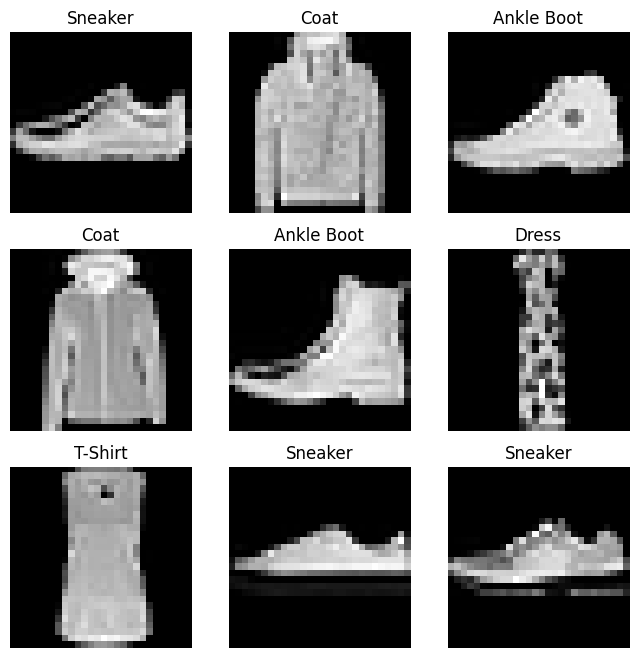

In [ ]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### 4. **Preparing your data for training with DataLoaders**
---
Passing dataset through DataLoader to iterate throught it

In [ ]:
# train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
# validation_dataloader = DataLoader(validation_data, batch_size=64, shuffle=True)
# test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


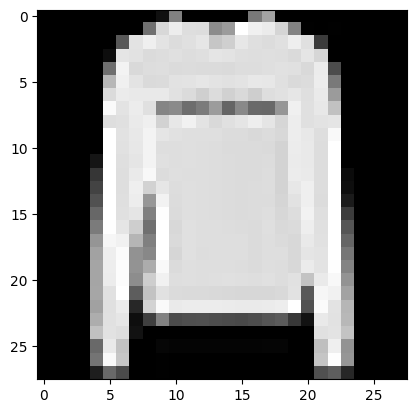

Label: 2


In [ ]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

In [ ]:
#to see the shape of the train loader
print(next(iter(train_dataloader))[0].shape)

torch.Size([64, 1, 28, 28])


### 5. **BUILDING THE NEURAL NETWORK**

---
Applying ML Algorithm on the dataset for classification using Pytorch

**Define the Class**:

We define our neural network by subclassing **nn.Module**, and initialize the neural network layers in __ init __. Every nn.Module subclass implements the operations on input data in the forward method.



In [ ]:
class FashionMNISTModel(torch.nn.Module):
    def __init__(self):
        super(FashionMNISTModel, self).__init__()
        self.flatten = torch.nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
                                    nn.Linear(28*28, 512),
                                    nn.ReLU(),
                                    nn.Dropout(0.2),
                                    nn.Linear(512, 256),
                                    nn.ReLU(),
                                    nn.Dropout(0.2),
                                    nn.Linear(256, 10),
                                    )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = FashionMNISTModel()

In [ ]:
print(model)

FashionMNISTModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)


#### 5.1 **DEFINING A LOSS FUNCTION**

---
Define a loss function that would be used to trace the training accuracy of the model



In [ ]:
def weight_init_normal(m):
    classname=m.__class__.__name__
    if classname.find('Linear')!=-1:
        n = m.in_features
        y = (1.0/np.sqrt(n))
        m.weight.data.normal_(0, y)
        m.bias.data.fill_(0)

model.apply(weight_init_normal)
print(model)

FashionMNISTModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [ ]:
learning_rate = 1e-3
# batch_size = 64
epochs = 25

In [ ]:
# Loss Function
# If we did not compute softmax at output use nn.CrossentropyLoss() else use nn.NLLLoss()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)

#### 5.2 **TRAINING & VALIDATION PHASE**

---
This section of the notebook is to train the model and validate the training on the validation set



In [ ]:
def train_loop(model, epochs, optimizer):
    """
    Description: This function trains the model
                 on the training dataset and
                 validate it on the validation
                 dataset.
    Input:       1) epochs-> the number of epochs to train the model
                 2) learning_rate-> the learning rate to train the model
                 3) optimiser-> the optimiser to train the model
    Output: None -> Trained Model
    """
    loss_keeper={'train':[],'valid':[]}

    # minimum validation loss ----- set initial minimum to infinity
    valid_loss_min = np.Inf



    model.train() # TURN ON DROPOUT for training

    for epoch in range(epochs):
        train_loss=0.0
        valid_loss=0.0

        """
        TRAINING PHASE
        """
         # TURN ON DROPOUT for training
        for images,labels in train_dataloader:
            if device == 'cuda':
                model = model.to(device)
                images,labels=images.to(device),labels.to(device)
            optimizer.zero_grad()
            output=model(images)
            loss=criterion(output,labels)
            loss.backward()
            optimizer.step()
            train_loss+=loss.item()

        """
        VALIDATION PHASE
        """
        model.eval() # TURN OFF DROPOUT for validation
        for images,labels in validation_dataloader:
            if device == 'cuda':
                model = model.to(device)
                images,labels=images.to(device),labels.to(device)
            output=model(images)
            loss=criterion(output,labels)
            valid_loss+=loss.item()

        # Calculating loss over entire batch size for every epoch
        train_loss = train_loss/len(train_dataloader)
        valid_loss = valid_loss/len(validation_dataloader)


        # saving loss values
        loss_keeper['train'].append(train_loss)
        loss_keeper['valid'].append(valid_loss)
        print(f"\nEpoch : {epoch+1}\tTraining Loss : {train_loss}\tValidation Loss : {valid_loss}")
        if valid_loss<=valid_loss_min:
            print(f"Validation loss decreased from : {valid_loss_min} ----> {valid_loss} ----> Saving Model.......")
            z=type(model).__name__
            torch.save(model.state_dict(), z+'_model.pth')
            valid_loss_min=valid_loss
    return(loss_keeper)

In [ ]:
model_trained = train_loop(model= model, epochs = epochs, optimizer=optimizer)


Epoch : 1	Training Loss : 0.5387335629264514	Validation Loss : 0.3853157042981462
Validation loss decreased from : inf ----> 0.3853157042981462 ----> Saving Model.......

Epoch : 2	Training Loss : 0.3726101329624653	Validation Loss : 0.35313872913730904
Validation loss decreased from : 0.3853157042981462 ----> 0.35313872913730904 ----> Saving Model.......

Epoch : 3	Training Loss : 0.33495290477077166	Validation Loss : 0.32095362713679354
Validation loss decreased from : 0.35313872913730904 ----> 0.32095362713679354 ----> Saving Model.......

Epoch : 4	Training Loss : 0.30861044309536617	Validation Loss : 0.2967543163673675
Validation loss decreased from : 0.32095362713679354 ----> 0.2967543163673675 ----> Saving Model.......

Epoch : 5	Training Loss : 0.2857125028570493	Validation Loss : 0.3244376994193868

Epoch : 6	Training Loss : 0.2737661762634913	Validation Loss : 0.3182823764992521

Epoch : 7	Training Loss : 0.26013516561190286	Validation Loss : 0.29494294306223695
Validation l

In [ ]:
model_trained

{'train': [0.5387335629264514,
  0.3726101329624653,
  0.33495290477077166,
  0.30861044309536617,
  0.2857125028570493,
  0.2737661762634913,
  0.26013516561190286,
  0.24531706604361533,
  0.23480686690409977,
  0.22390848402678967,
  0.21549104113380113,
  0.20648271120587985,
  0.19667016039788723,
  0.18480469510455927,
  0.18159032321472962,
  0.17328970537583033,
  0.1677444582382838,
  0.16086761385947465,
  0.155307823933661,
  0.14883715885380905,
  0.1449784074301521,
  0.14108037486920755,
  0.13389165922502677,
  0.1276388293032845,
  0.12715245005736747],
 'valid': [0.3853157042981462,
  0.35313872913730904,
  0.32095362713679354,
  0.2967543163673675,
  0.3244376994193868,
  0.3182823764992521,
  0.29494294306223695,
  0.29187232755283093,
  0.3070553546731776,
  0.2984850985255647,
  0.2985848104383083,
  0.28096571802458864,
  0.30753510691067004,
  0.3253473402496348,
  0.301540439334163,
  0.29559209998300734,
  0.3011519536574153,
  0.31082836564313227,
  0.33109177

In [ ]:
# Loading the model from the lowest validation loss
model.load_state_dict(torch.load('FashionMNISTModel_model.pth'))

<ipython-input-27-e7fe890f1832>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('FashionMNISTModel_model.pth'))


<All keys matched successfully>

In [ ]:
print(model.state_dict)

<bound method Module.state_dict of FashionMNISTModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)>


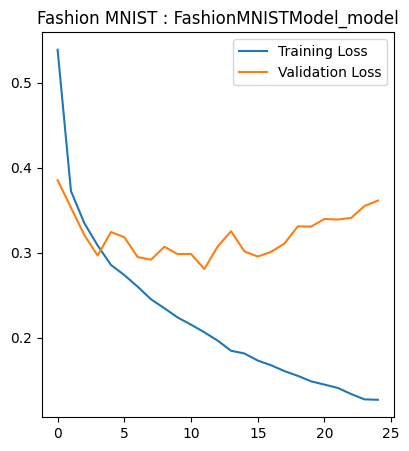

In [ ]:
title=['FashionMNISTModel_model']
model_losses=[model_trained]
fig=plt.figure(1,figsize=(10,5))
idx=1
for i in model_losses:
  ax=fig.add_subplot(1,2,idx)
  ax.plot(i['train'],label="Training Loss")
  ax.plot(i['valid'],label="Validation Loss")
  ax.set_title('Fashion MNIST : '+title[idx-1])
  idx+=1
  plt.legend();

In [ ]:
def test(model):
    correct=0
    test_loss=0
    class_correct = list(0. for i in range(10))
    class_total = list(0. for i in range(10))

    model.eval() # test the model with dropout layers off
    for images,labels in test_dataloader:
        if device=='cuda':
            model = model.to(device)
            images,labels=images.to(device),labels.to(device)
        output=model(images)
        loss=criterion(output,labels)
        test_loss+=loss.item()
        _,pred=torch.max(output,1)
        correct = np.squeeze(pred.eq(labels.data.view_as(pred)))

        for i in range(len(images)):
            label = labels.data[i]
            class_correct[label] += correct[i].item()
            class_total[label] += 1


    test_loss=test_loss/len(test_dataloader)
    print(f'For {type(model).__name__} :')
    print(f"Test Loss: {test_loss}")
    print(f"Correctly predicted per class : {class_correct}, Total correctly perdicted : {sum(class_correct)}")
    print(f"Total Predictions per class : {class_total}, Total predictions to be made : {sum(class_total)}\n")
    for i in range(10):
      if class_total[i] > 0:
          print(f"Test Accuracy of class {labels_map[i]} : {float(100 * class_correct[i] / class_total[i])}% where {int(np.sum(class_correct[i]))} of {int(np.sum(class_total[i]))} were predicted correctly")
      else:
          print('Test Accuracy of %5s: N/A (no training examples)' % (labels_map[i]))

    print(f"\nOverall Test Accuracy : {float(100. * np.sum(class_correct) / np.sum(class_total))}% where {int(np.sum(class_correct))} of {int(np.sum(class_total))} were predicted correctly")
    # obtain one batch of test images
    dataiter = iter(test_dataloader)
    images, labels = next(dataiter)

    # # get sample outputs
    if device=='cuda':
        model = model.to(device)
        images,labels=images.to(device),labels.to(device)
    output = model(images)

    # # convert output probabilities to predicted class
    _, preds = torch.max(output, 1)
    # prep images for display
    images = images.cpu().numpy()

    fig = plt.figure(figsize=(15, 20))
    for idx in np.arange(batch_size):
        ax = fig.add_subplot(5, batch_size/5, idx+1, xticks=[], yticks=[])
        plt.imshow(np.squeeze(images[idx]))
        ax.set_title("{}-{} for ({}-{})".format(str(preds[idx].item()), labels_map[preds[idx].item()],str(labels[idx].item()),labels_map[labels[idx].item()]),
                    color=("blue" if preds[idx]==labels[idx] else "red"))

In [ ]:
test(model)

For FashionMNISTModel :
Test Loss: 0.3305468760478269
Correctly predicted per class : [886.0, 974.0, 728.0, 870.0, 859.0, 946.0, 693.0, 978.0, 971.0, 954.0], Total correctly perdicted : 8859.0
Total Predictions per class : [1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0, 1000.0], Total predictions to be made : 10000.0

Test Accuracy of class T-Shirt : 88.6% where 886 of 1000 were predicted correctly
Test Accuracy of class Trouser : 97.4% where 974 of 1000 were predicted correctly
Test Accuracy of class Pullover : 72.8% where 728 of 1000 were predicted correctly
Test Accuracy of class Dress : 87.0% where 870 of 1000 were predicted correctly
Test Accuracy of class Coat : 85.9% where 859 of 1000 were predicted correctly
Test Accuracy of class Sandal : 94.6% where 946 of 1000 were predicted correctly
Test Accuracy of class Shirt : 69.3% where 693 of 1000 were predicted correctly
Test Accuracy of class Sneaker : 97.8% where 978 of 1000 were predicted correctly
Test A

In [ ]:
for images,labels in test_dataloader:
    print(labels)

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 4, 8, 0, 2, 5, 7, 9,
        1, 4, 6, 0, 9, 3, 8, 8, 3, 3, 8, 0, 7, 5, 7, 9, 6, 1, 3, 7, 6, 7, 2, 1,
        2, 2, 4, 4, 5, 8, 2, 2, 8, 4, 8, 0, 7, 7, 8, 5])
tensor([1, 1, 2, 3, 9, 8, 7, 0, 2, 6, 2, 3, 1, 2, 8, 4, 1, 8, 5, 9, 5, 0, 3, 2,
        0, 6, 5, 3, 6, 7, 1, 8, 0, 1, 4, 2, 3, 6, 7, 2, 7, 8, 5, 9, 9, 4, 2, 5,
        7, 0, 5, 2, 8, 6, 7, 8, 0, 0, 9, 9, 3, 0, 8, 4])
tensor([1, 5, 4, 1, 9, 1, 8, 6, 2, 1, 2, 5, 1, 0, 0, 0, 1, 6, 1, 6, 2, 2, 4, 4,
        1, 4, 5, 0, 4, 7, 9, 3, 7, 2, 3, 9, 0, 9, 4, 7, 4, 2, 0, 5, 2, 1, 2, 1,
        3, 0, 9, 1, 0, 9, 3, 6, 7, 9, 9, 4, 4, 7, 1, 2])
tensor([1, 6, 3, 2, 8, 3, 6, 1, 1, 0, 2, 9, 2, 4, 0, 7, 9, 8, 4, 1, 8, 4, 1, 3,
        1, 6, 7, 2, 8, 5, 2, 0, 7, 7, 6, 2, 7, 0, 7, 8, 9, 2, 9, 0, 5, 1, 4, 4,
        5, 6, 9, 2, 6, 8, 6, 4, 2, 2, 9, 7, 6, 5, 5, 2])
tensor([8, 5, 2, 3, 0, 4, 8, 0, 0, 6, 3, 8, 9, 6, 1, 3, 0, 2, 3, 0, 8, 3, 7, 4,
        0, 1, 6, 3, 0, 6, 6, 7, 5, 4, 5, 9, 5, 6, 5,